# Semantic Segmentation Image Model to Investigate Chip Images

### Importing Required Libraries

In [1]:
import pickle
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torchvision.transforms.functional as F
from torchvision import models
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from tqdm import tqdm
import seaborn as sns
from PIL import Image
from typing import List, Tuple
import torch.nn.functional as Fnn

### Setting up the GPU Device

In [2]:
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:2


### Setting the seed for reproducibility

In [3]:
SEED = 42 # For reproducibility

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

## DATA PREPARATION

In [5]:
COLOR2ID = {
    (0, 0, 0):   0,  # black background
    (255, 0, 0): 1,  # red for fill
}
NUM_CLASSES = len(COLOR2ID)
mask_directory = Path('imaging/Images_fill/')
dataset_directory = Path('imaging/data_cropped_images/')


In [6]:
def color_mask_to_label(mask_rgb):
    """
    mask_rgb: HxWx3 uint8 array (RGB)
    returns:  HxW uint8 label mask with class ids
    """
    H, W, _ = mask_rgb.shape
    lab = np.zeros((H, W), dtype=np.uint8)
    for color, cid in COLOR2ID.items():
        # boolean mask for this exact color
        m = (mask_rgb == np.array(color, dtype=np.uint8)).all(axis=2)
        lab[m] = cid
    return lab

In [7]:
def ensure_same_size():
    for cropped_image in Path('imaging/data_cropped_images/').glob('*.png'):
        label_image = cv2.imread(f"{Path('imaging/Images_fill/')}/{cropped_image.name.replace('_cropped', '_poly_fill')}", cv2.IMREAD_GRAYSCALE)
        cropped = cv2.imread(str(cropped_image), cv2.IMREAD_GRAYSCALE)
        if cropped.shape != label_image.shape:
            print(f"Size mismatch for {cropped_image.name}, resizing cropped image.")

In [8]:
ensure_same_size()

In [9]:
def build_patch_index(
    image_dir: Path,
    mask_dir: Path,
    file_list: List[str],
    patch_size: int = 256,
    stride: int = 128, # Overlapping patches
    min_foreground_ratio: float = 0.0,
) -> List[Tuple[int, int, int]]:
    index = []
    for file_idx, file in enumerate(file_list):
        image_path = image_dir / file
        mask_path = mask_dir / file.replace('_cropped', '_poly_fill')
        mask_image = Image.open(str(mask_path)).convert('RGB')
        mask_array = color_mask_to_label(np.array(mask_image)) # The dimensions are (H, W)
        H, W = mask_array.shape
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                mask_patch = mask_array[y:y+patch_size, x:x+patch_size]
                if min_foreground_ratio > 0.0:
                    foreground_pixels = (mask_patch != 0).sum()
                    total_pixels = mask_patch.size
                    if foreground_pixels / total_pixels >= min_foreground_ratio:
                        index.append((file_idx, y, x))
                    else:
                        continue
    return index

    

### Defining the Dataset class and Building the Dataset

In [10]:
# Defining Constants
BATCH_SIZE = 32
PATCH_SIZE = 256
STRIDE = 128
MIN_FOREGROUND_RATIO = 0.01 # Have at least 1% logic pixels in a patch (tried 10% before)

In [11]:
class ChipPatchSegmentationDataset(Dataset):
    def __init__(
        self,
        image_dir: Path,
        mask_dir: Path,
        file_list: List[str],
        patch_size: int = 256,
        stride: int = 128,
        min_foreground_ratio: float = 0.0,
        use_grayscale: bool = True,
        train: bool = True,
        augment: bool = True, 
    ):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.file_list = file_list
        self.patch_size = patch_size
        self.stride = stride
        self.min_foreground_ratio = min_foreground_ratio
        self.train = train
        self.augment = augment
        self.use_grayscale = use_grayscale

        self.index = build_patch_index(
            image_dir = image_dir,
            mask_dir = mask_dir,
            file_list = file_list,
            patch_size = patch_size,
            stride = stride,
            min_foreground_ratio = min_foreground_ratio,
        )

        if len(self.index) == 0:
            raise ValueError("No patches found with the specified min_foreground_ratio.")
        
        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        file_idx, y, x = self.index[idx]
        file_name = self.file_list[file_idx]
        image_path = self.image_dir / file_name
        mask_path = self.mask_dir / file_name.replace('_cropped', '_poly_fill')

        image = Image.open(str(image_path)).convert('RGB')
        if self.use_grayscale:
            image = image.convert('L')
        else:
            image = image.convert('RGB')
        mask_image = Image.open(str(mask_path)).convert('RGB')
        mask_array = color_mask_to_label(np.array(mask_image))

        image_patch = F.crop(image, y, x, self.patch_size, self.patch_size)
        mask_patch_array = mask_array[y:y + self.patch_size, x:x + self.patch_size]

        if self.train and self.augment:
            if np.random.rand() > 0.5:
                image_patch = F.hflip(image_patch)
                mask_patch_array = np.fliplr(mask_patch_array)
            if np.random.rand() > 0.5:
                image_patch = F.vflip(image_patch)
                mask_patch_array = np.flipud(mask_patch_array)
        mask_patch_array = np.ascontiguousarray(mask_patch_array)
        image_tensor = self.to_tensor(image_patch) # [C, H, W] = torch.float32 in [0.0, 1.0]
        if self.use_grayscale:
            image_tensor = image_tensor.repeat(3, 1, 1) # Because ResNet expects 3 channels
        
        image_tensor = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image_tensor)
        mask_patch = torch.from_numpy(mask_patch_array).long() # [H, W] = torch.int64 with class ids

        return image_tensor, mask_patch

In [12]:
all_files = sorted([f.name for f in dataset_directory.glob('*_cropped.png')])
train, temp = train_test_split(all_files, test_size=0.3, random_state=SEED)
test, val = train_test_split(temp, test_size=0.5, random_state=SEED)
train_dataset = ChipPatchSegmentationDataset(
    image_dir=dataset_directory,
    mask_dir=mask_directory,
    file_list=train,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_foreground_ratio=MIN_FOREGROUND_RATIO,
    use_grayscale=False,
    train=True,
    augment=True,
)
val_dataset = ChipPatchSegmentationDataset(
    image_dir=dataset_directory,
    mask_dir=mask_directory,
    file_list=val,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_foreground_ratio=MIN_FOREGROUND_RATIO,
    use_grayscale=False,
    train=False,
    augment=False,
)
test_dataset = ChipPatchSegmentationDataset(
    image_dir=dataset_directory,
    mask_dir=mask_directory,
    file_list=test,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_foreground_ratio=MIN_FOREGROUND_RATIO,
    use_grayscale=False,
    train=False,
    augment=False,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [13]:
print("Train Counts:", len(train_dataset.index))
print("Validation Counts:", len(val_dataset.index))
print("Test Counts:", len(test_dataset.index))

print(train)
print(val)
print(test)

Train Counts: 1439
Validation Counts: 1156
Test Counts: 361
['housekeeping_cropped.png', 'wrapped_snn_network_cropped.png', 'wb_openram_wrapper_cropped.png', 'wrapped_function_generator_cropped.png', 'wrapped_etpu_cropped.png', 'wrapped_mbsFSK_cropped.png']
['wrapped_silife_cropped.png', 'wb_bridge_2way_cropped.png']
['wrapped_ibnalhaytham_cropped.png']


## Model Definition

In [14]:
'''resnet = models.resnet18(weights = models.ResNet18_Weights.IMAGENET1K_V1)
print(resnet)'''

'resnet = models.resnet18(weights = models.ResNet18_Weights.IMAGENET1K_V1)\nprint(resnet)'

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv_net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_net(x)
    
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=3):
        super(UNet, self).__init__()
        
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        
        self.pool = nn.MaxPool2d(2)
        
        self.bottleneck = DoubleConv(512, 1024)
        
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        self.conv_last = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        
        # Bottleneck
        b = self.bottleneck(self.pool(e4))
        
        # Decoder
        d4 = self.upconv4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.upconv3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        logits = self.conv_last(d1)
        
        return logits

In [16]:
def compute_class_weights(dataset: Dataset) -> torch.Tensor:
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    counts = torch.zeros(NUM_CLASSES, dtype=torch.long)

    for index_val, (_, mask) in enumerate(loader):
        mask_flat = mask.view(-1)
        for c in range(NUM_CLASSES):
            counts[c] += (mask_flat == c).sum()

    frequencies = counts.float() / counts.sum().float()
    eps = 1e-6 # For numerical stability 
    inverse_frequencies = 1.0 / (frequencies + eps)

    class_weights = inverse_frequencies / inverse_frequencies.mean()
    return class_weights
        


In [17]:
def dice_loss_multiclass(logits, targets, smooth=1e-6):
    """
    logits: [B, C, H, W] - raw output from the model
    targets: [B, H, W] - ground truth class ids
    """
    B, C, H, W = logits.shape
    probs = Fnn.softmax(logits, dim=1)  # [B, C, H, W]
    targets_one_hot = Fnn.one_hot(targets, num_classes=C).permute(0, 3, 1, 2).float()  # [B, C, H, W]
    dims = (0, 2, 3)  # Sum over batch and spatial dimensions
    intersection = torch.sum(probs * targets_one_hot, dim=dims)  # [C]
    cardinality = torch.sum(probs + targets_one_hot, dim=dims)  # [C]

    dice_score = (2.0 * intersection + smooth) / (cardinality + smooth)  # [C]
    dice_loss = 1.0 - dice_score.mean()  # [C]
    return dice_loss  # Average over batch and classes

In [18]:
class ComboLoss(nn.Module):
    def __init__(self, class_weight=None, dice_weight=0.5):
        super(ComboLoss, self).__init__()
        if class_weight is not None:
            self.ce_loss = nn.CrossEntropyLoss(weight=class_weight)
        else:
            self.ce_loss = nn.CrossEntropyLoss()
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)
        dice = dice_loss_multiclass(logits, targets)
        return ce * (1 - self.dice_weight) + dice * self.dice_weight

In [19]:
def train_loop(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss, correct_pixels, total_pixels = 0.0, 0, 0
    train_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Train]", leave=False)

    for images, masks in train_iter:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        npx = masks.numel()
        running_loss += loss.item() * npx

        preds = logits.argmax(dim=1) # [B, H, W]
        correct_pixels += (preds == masks).sum().item()
        total_pixels += npx
    avg_loss = running_loss / total_pixels
    accuracy = correct_pixels / total_pixels
    print(f"Epoch {epoch:03d} Train Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy

In [20]:
def validation_loop(model, data_loader, criterion, device, epoch):
    model.eval()
    running_loss, correct_pixels, total_pixels = 0.0, 0, 0
    eval_iter = tqdm(data_loader, desc=f"Epoch {epoch:03d} [Eval]", leave=False)

    with torch.no_grad():
        for images, masks in eval_iter:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)

            npx = masks.numel()
            running_loss += loss.item() * npx

            preds = logits.argmax(dim=1) # [B, H, W]
            correct_pixels += (preds == masks).sum().item()
            total_pixels += npx
    avg_loss = running_loss / total_pixels
    accuracy = correct_pixels / total_pixels

    print(f"Epoch {epoch:03d} Eval Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy

In [21]:
def test_loop(model, data_loader, criterion, device):
    model.eval()
    all_preds = []
    all_targets = []
    running_loss, correct_pixels, total_pixels = 0.0, 0, 0
    test_iter = tqdm(data_loader, desc=f"[Testing]", leave=False)
    
    with torch.no_grad():
        for images, masks in test_iter:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            preds = logits.argmax(dim=1) # [B, H, W]

            loss = criterion(logits, masks)
            npx = masks.numel()
            running_loss += loss.item() * npx
            correct_pixels += (preds == masks).sum().item()
            total_pixels += npx
            all_preds.append(preds.cpu().numpy())
            all_targets.append(masks.cpu().numpy())

    
    avg_loss = running_loss / total_pixels
    accuracy = correct_pixels / total_pixels

    print(f"Test Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    all_preds = np.concatenate(all_preds, axis=0).flatten()
    all_targets = np.concatenate(all_targets, axis=0).flatten()

    print("Classification Report:")
    print(classification_report(all_targets, all_preds, labels=list(range(NUM_CLASSES)), zero_division=0))

    cm = confusion_matrix(all_targets, all_preds, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(COLOR2ID.values()), yticklabels=list(COLOR2ID.values()))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    return avg_loss, accuracy

In [22]:
class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0.0, mode = 'max', restore_best_weights = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_path = "UNet_Segmentation_fill_best_model.pth"
    
    def is_improved(self, current_score):
        if self.best_score is None:
            return True
        if self.mode == 'max':
            return current_score > self.best_score + self.min_delta
        else: # in the case of 'min'
            return current_score < self.best_score - self.min_delta
        
    def step(self, current_score, model):
        if self.is_improved(current_score):
            self.best_score = current_score
            self.counter = 0
            torch.save(model.state_dict(), self.best_path)
        else:
            self.counter += 1
            return self.counter >= self.patience
        
    def restore_weights(self, model, map_location=None):
        if self.restore_best_weights and self.best_score is not None:
            model.load_state_dict(torch.load(self.best_path, map_location=map_location))
        

In [23]:
class_weights = compute_class_weights(train_dataset)
class_weights = class_weights.to(device)
criterion = ComboLoss(
    class_weight=class_weights, 
    dice_weight=0.5,
)
model = UNet(in_channels=3, out_channels=NUM_CLASSES).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)


In [24]:
'''small_index = list(range(10))
small_ds = torch.utils.data.Subset(train_dataset, small_index)
small_loader = DataLoader(small_ds, batch_size=2, shuffle=True)

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    small_loss = train_loop(model, small_loader, criterion, optimizer, device, epoch)

    print(f"Epoch {epoch:02d} | Train Loss: {small_loss[0]:.4f}, Train Acc: {small_loss[1]:.4f}")'''


'small_index = list(range(10))\nsmall_ds = torch.utils.data.Subset(train_dataset, small_index)\nsmall_loader = DataLoader(small_ds, batch_size=2, shuffle=True)\n\nEPOCHS = 100\n\nfor epoch in range(1, EPOCHS + 1):\n    print(f"Epoch {epoch}/{EPOCHS}")\n    small_loss = train_loop(model, small_loader, criterion, optimizer, device, epoch)\n\n    print(f"Epoch {epoch:02d} | Train Loss: {small_loss[0]:.4f}, Train Acc: {small_loss[1]:.4f}")'

In [25]:
# TRAINING

EPOCHS = 200
best_val = -float('inf')
best_epoch = 0
stopper = EarlyStopping(patience=5, min_delta=1e-4, mode='max', restore_best_weights=True)

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss = train_loop(model, train_loader, criterion, optimizer, device, epoch)
    val_loss = validation_loop(model, val_loader, criterion, device, epoch)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss[0]:.4f}, Train Acc: {train_loss[1]:.4f} | Val Loss: {val_loss[0]:.4f}, Val Acc: {val_loss[1]:.4f}")

    if val_loss[1] > best_val:
        best_val = val_loss[1]
        best_epoch = epoch
        torch.save(model.state_dict(), "UNet_Segmentation_fill_best_model.pth")
        print(f"New best model found at epoch {epoch}")
    
    '''if stopper.step(val_loss[1], model):
        print(f"Early stopping at epoch {epoch}: Best epoch was {best_epoch} with validation accuracy {best_val:.4f}.")
        stopper.restore_weights(model, map_location=device)
        break'''
    
    
print(f"Training complete. Best validation accuracy: {best_val:.4f} at epoch {best_epoch}")

Epoch 1/200


Epoch 001 Train Loss: 0.4697, Accuracy: 0.7529


Epoch 001 Eval Loss: 0.5658, Accuracy: 0.6095
Epoch 01 | Train Loss: 0.4697, Train Acc: 0.7529 | Val Loss: 0.5658, Val Acc: 0.6095
New best model found at epoch 1
Epoch 2/200


Epoch 002 Train Loss: 0.4582, Accuracy: 0.7648


Epoch 002 Eval Loss: 0.5631, Accuracy: 0.5886
Epoch 02 | Train Loss: 0.4582, Train Acc: 0.7648 | Val Loss: 0.5631, Val Acc: 0.5886
Epoch 3/200


...

Epoch 198 Eval Loss: 1.2836, Accuracy: 0.6069
Epoch 198 | Train Loss: 0.0329, Train Acc: 0.9835 | Val Loss: 1.2836, Val Acc: 0.6069
Epoch 199/200


Epoch 199 Train Loss: 0.0344, Accuracy: 0.9828


Epoch 199 Eval Loss: 1.3909, Accuracy: 0.6040
Epoch 199 | Train Loss: 0.0344, Train Acc: 0.9828 | Val Loss: 1.3909, Val Acc: 0.6040
Epoch 200/200


Epoch 200 Train Loss: 0.0304, Accuracy: 0.9849


Epoch 200 Eval Loss: 1.3680, Accuracy: 0.6069
Epoch 200 | Train Loss: 0.0304, Train Acc: 0.9849 | Val Loss: 1.3680, Val Acc: 0.6069
Training complete. Best validation accuracy: 0.6344 at epoch 41


[Testing]:  33%|███▎      | 4/12 [00:13<00:15,  1.92s/it]

Test Loss: 0.4981, Accuracy: 0.6733
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.91      0.78  15387656
           1       0.58      0.23      0.33   8270840

    accuracy                           0.67  23658496
   macro avg       0.64      0.57      0.56  23658496
weighted avg       0.65      0.67      0.63  23658496



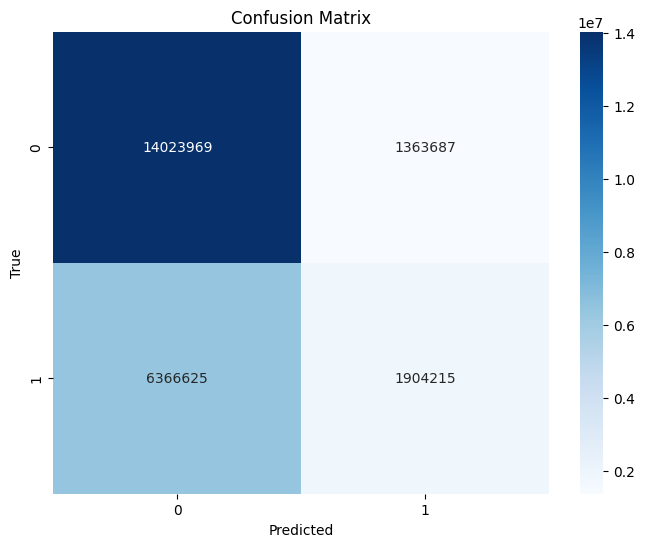

Test Loss: 0.4981, Test Accuracy: 0.6733


In [26]:
# Load the best model for testing

model.load_state_dict(torch.load("UNet_Segmentation_fill_best_model.pth"))
test_loss = test_loop(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss[0]:.4f}, Test Accuracy: {test_loss[1]:.4f}")

Test Loss: 0.3913, Accuracy: 0.7932
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.70  31080171
           1       0.87      0.82      0.84  63226133

    accuracy                           0.79  94306304
   macro avg       0.77      0.78      0.77  94306304
weighted avg       0.80      0.79      0.80  94306304



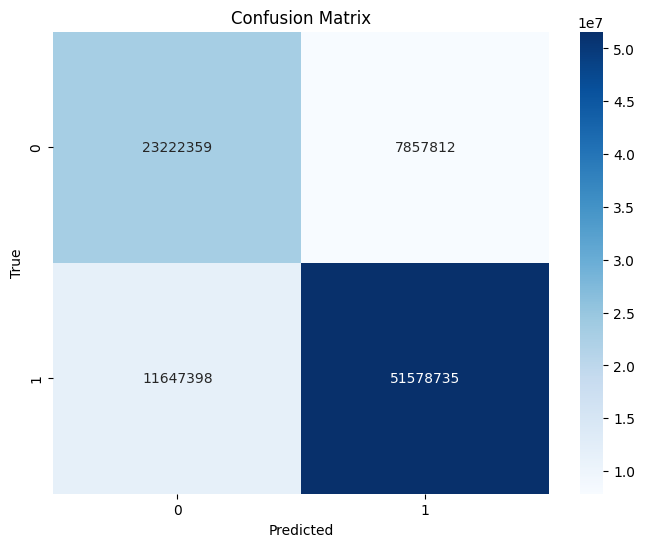

Train Loss: 0.3913, Train Accuracy: 0.7932


In [27]:
train_performance = test_loop(model, train_loader, criterion, device)
print(f"Train Loss: {train_performance[0]:.4f}, Train Accuracy: {train_performance[1]:.4f}")

Test Loss: 0.5498, Accuracy: 0.6344
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.76      0.67  36703092
           1       0.70      0.51      0.59  39056524

    accuracy                           0.63  75759616
   macro avg       0.65      0.64      0.63  75759616
weighted avg       0.65      0.63      0.63  75759616



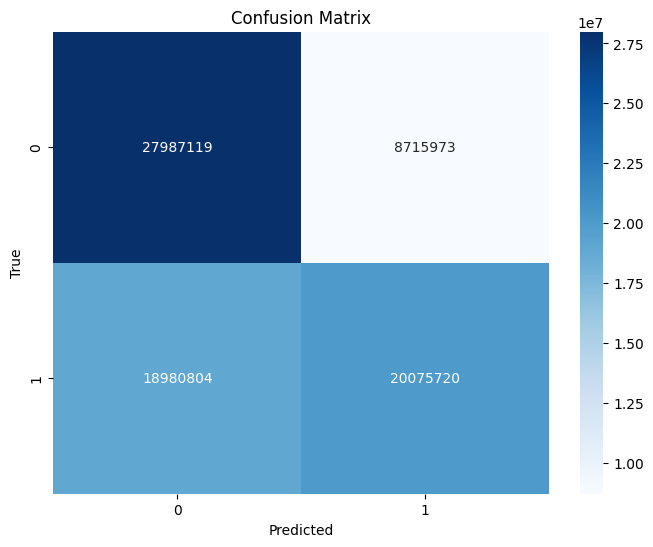

Valid Loss: 0.5498, Valid Accuracy: 0.6344


In [28]:
validation_performance = test_loop(model, val_loader, criterion, device)
print(f"Valid Loss: {validation_performance[0]:.4f}, Valid Accuracy: {validation_performance[1]:.4f}")

In [30]:
print(best_epoch)

41
